In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Resume.csv")

df.head()

Saving Resume.csv to Resume.csv


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2484, 4)

Columns:
['ID', 'Resume_str', 'Resume_html', 'Category']

Missing Values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [4]:
df = df.dropna(subset=["Resume_str"])

df["resume_text"] = (
    df["Resume_str"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df = df.drop_duplicates(subset=["resume_text"]).reset_index(drop=True)

print("Resumes after cleaning:", len(df))

Resumes after cleaning: 2482


In [5]:
job_description = """
We are looking for a Software Engineer with strong skills in Python,
Java, SQL, Machine Learning, Data Structures, Algorithms, Git,
Problem Solving, Cloud Computing, APIs, and Software Development.
Candidates should have strong programming and analytical skills.
"""

In [6]:
required_skills = [
    "python",
    "java",
    "sql",
    "machine learning",
    "data structures",
    "algorithms",
    "git",
    "problem solving",
    "cloud",
    "api",
    "software development"
]

In [7]:
documents = [job_description.lower()] + df["resume_text"].tolist()

vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform(documents)

similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
).flatten()

df["similarity_score"] = similarity_scores * 100

In [8]:
def find_skills(text):
    return [
        skill for skill in required_skills
        if skill in text
    ]

df["matched_skills"] = df["resume_text"].apply(find_skills)

df["skill_score"] = (
    df["matched_skills"].apply(len)
    / len(required_skills)
) * 100

In [9]:
df["final_score"] = (
    0.6 * df["similarity_score"] +
    0.4 * df["skill_score"]
)

df = df.sort_values(
    "final_score",
    ascending=False
).reset_index(drop=True)

df["rank"] = df.index + 1

In [10]:
df["missing_skills"] = df["resume_text"].apply(
    lambda text: [
        skill for skill in required_skills
        if skill not in text
    ]
)

In [11]:
top_candidates = df[
    [
        "rank",
        "Category",
        "final_score",
        "similarity_score",
        "skill_score",
        "matched_skills",
        "missing_skills"
    ]
].head(10)

top_candidates

,rank,Category,final_score,similarity_score,skill_score,matched_skills,missing_skills
0,1,INFORMATION-TECHNOLOGY,40.754121,19.438687,72.727273,"[java, sql, algorithms, git, problem solving, ...","[python, machine learning, data structures]"
1,2,BANKING,33.558344,13.506331,63.636364,"[java, sql, git, problem solving, cloud, api, ...","[python, machine learning, data structures, al..."
2,3,ENGINEERING,31.822962,16.674634,54.545455,"[java, machine learning, git, cloud, api, soft...","[python, sql, data structures, algorithms, pro..."
3,4,AGRICULTURE,31.810166,16.653307,54.545455,"[python, java, sql, algorithms, api, software ...","[machine learning, data structures, git, probl..."
4,5,CONSULTANT,31.553128,16.224910,54.545455,"[python, java, sql, machine learning, api, sof...","[data structures, algorithms, git, problem sol..."
5,6,ENGINEERING,31.475418,16.095394,54.545455,"[python, java, sql, git, api, software develop...","[machine learning, data structures, algorithms..."
6,7,AVIATION,30.740889,14.871178,54.545455,"[python, java, sql, git, api, software develop...","[machine learning, data structures, algorithms..."
7,8,CONSTRUCTION,29.129420,18.246003,45.454545,"[java, sql, data structures, algorithms, probl...","[python, machine learning, git, cloud, api, so..."
8,9,CONSULTANT,28.116059,16.557068,45.454545,"[java, sql, git, api, software development]","[python, machine learning, data structures, al..."
9,10,BANKING,27.322931,9.174581,54.545455,"[java, sql, problem solving, cloud, api, softw...","[python, machine learning, data structures, al..."


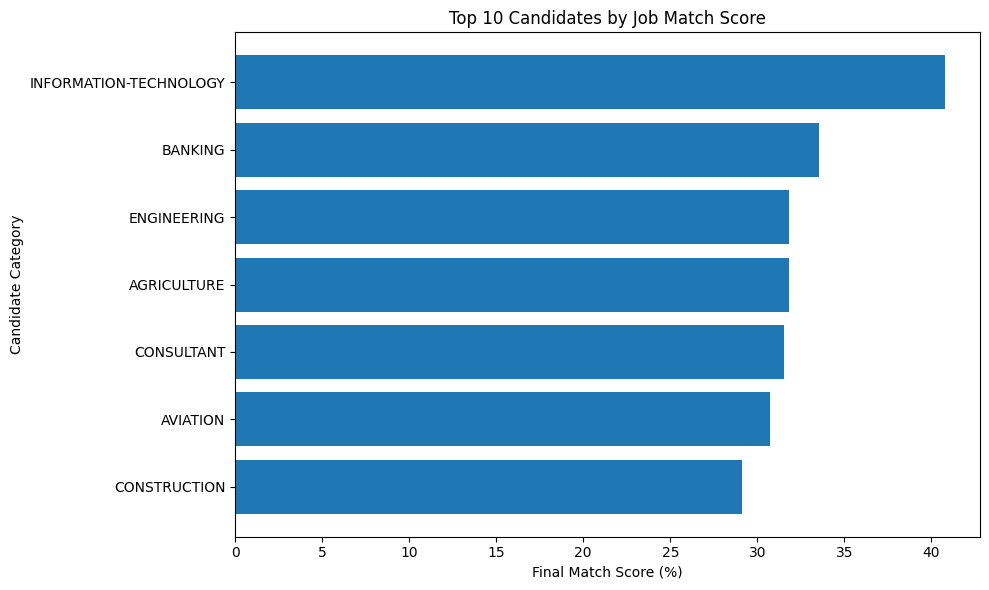

In [12]:
top = df.head(10).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top["Category"].astype(str),
    top["final_score"]
)

plt.xlabel("Final Match Score (%)")
plt.ylabel("Candidate Category")
plt.title("Top 10 Candidates by Job Match Score")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
best = df.iloc[0]

print("BEST CANDIDATE")
print("-------------------------")
print("Rank:", best["rank"])
print("Category:", best["Category"])
print("Final Match Score:", round(best["final_score"], 2), "%")
print("Similarity Score:", round(best["similarity_score"], 2), "%")
print("Skill Match Score:", round(best["skill_score"], 2), "%")
print("Matched Skills:", best["matched_skills"])
print("Missing Skills:", best["missing_skills"])

BEST CANDIDATE
-------------------------
Rank: 1
Category: INFORMATION-TECHNOLOGY
Final Match Score: 40.75 %
Similarity Score: 19.44 %
Skill Match Score: 72.73 %
Matched Skills: ['java', 'sql', 'algorithms', 'git', 'problem solving', 'cloud', 'api', 'software development']
Missing Skills: ['python', 'machine learning', 'data structures']
